In [310]:
import numpy as np
import seaborn as sns


eps = 1e-3
h = 0.1

start, end = 0, 1
x = np.arange(start, end + h, h)
y = lambda x: x + np.exp(-2 * x)

$
\begin{cases}
(2x+1)\,y'' + 4x\,y' - 4y = 0, \\
y'(0) = -1, \\
y'(1) + 2y(1) = 3.
\end{cases}
\qquad
y(x) = x + e^{-2x}
$


Преобразуем дифференциальное уравнение второго порядка к системе двух уравнений первого порядка, вводя $z = y'$:

$y' = z, \qquad z' = \frac{4y - 4xz}{2x + 1}$.


In [311]:
def error(v, v_etalon):
    return np.sum(np.abs(v - v_etalon))

In [312]:
def runge_romberg_richardson(f_h, f_kh, p, k_coef):
    return (f_h[::k_coef] - f_kh) / (k_coef ** p - 1)

## Метод стрельбы

Зададим функции правых частей системы:

$
y'=z,\qquad z'=\frac{4y-4xz}{2x+1}.
$

Также вычислим значения точного решения на основной сетке.


In [313]:
f_der_1 = lambda z: z
f_der_2 = lambda x, y, z: (4 * y - 4 * x * z) / (2 * x + 1)

y_etalon_f = y(x)

Метод Рунге–Кутты 4-го порядка для задачи Коши

In [314]:
def runge_kutta(y_der_1, y_der_2, x, y0, z0, h):
    y = np.zeros(len(x), dtype=np.float64)
    z = np.zeros(len(x), dtype=np.float64)

    y[0], z[0] = y0, z0

    for i in range(1, len(x)):
        K_k_1 = h * y_der_1(z[i - 1])
        L_k_1 = h * y_der_2(x[i - 1], y[i - 1], z[i - 1])


        K_k_2 = h * y_der_1(z[i - 1] + L_k_1 / 2)

        L_k_2 = h * y_der_2(x[i - 1] + h / 2, y[i - 1] + K_k_1 / 2, z[i - 1] + L_k_1 / 2)


        K_k_3 = h * y_der_1(z[i - 1] + L_k_2 / 2)

        L_k_3 = h * y_der_2(x[i - 1] + h / 2, y[i - 1] + K_k_2 / 2, z[i - 1] + L_k_2 / 2)


        K_k_4 = h * y_der_1(z[i - 1] + L_k_3)

        L_k_4 = h * y_der_2(x[i - 1] + h, y[i - 1] + K_k_3, z[i - 1] + L_k_3)


        y_delta = (K_k_1 + 2 * K_k_2 + 2 * K_k_3 + K_k_4) / 6
        z_delta = (L_k_1 + 2 * L_k_2 + 2 * L_k_3 + L_k_4) / 6


        y[i] = y[i - 1] + y_delta
        z[i] = z[i - 1] + z_delta

    return y, z

Неизвестное начальное значение обозначается как:

$
y(0)=s.
$

Для каждого s решается задача Коши:

$
y(0)=s,\qquad z(0)=y'(0)=-1.
$

После интегрирования до \(x=1\) проверяется правое граничное условие:

$
z(1)+2y(1)=3.
$

Невязка имеет вид:

$
\Phi(s)=z(1)+2y(1)-3.
$

Реализуем метод стрельбы:

In [315]:
def shooting_method(y_der_1, y_der_2, x, h, s0, s1, z0, eps=1e-3):

    def phi(s):
        y_tmp, z_tmp = runge_kutta(y_der_1, y_der_2, x, s, z0, h)
        return z_tmp[-1] + 2 * y_tmp[-1] - 3

    phi0 = phi(s0)
    phi1 = phi(s1)


    while True:
        if abs(phi1) <= eps:
            break

        if abs(phi1 - phi0) < 1e-15:
            raise ZeroDivisionError("Метод секущих остановлен: разность невязок слишком мала.")

        s2 = s1 - phi1 * (s1 - s0) / (phi1 - phi0)
        phi2 = phi(s2)

        s0, phi0 = s1, phi1
        s1, phi1 = s2, phi2

    y_result, z_result = runge_kutta(y_der_1, y_der_2, x, s1, z0, h)

    return s1, y_result, z_result

В качестве двух начальных приближений для неизвестного $(s=y(0))$ положим `s0 = 0` и `s1 = 2`, как пробные значения функции в левой точке. Из условия известно $(z(0)=y'(0)=-1)$.

Решим и провалидируем основные моменты:

In [316]:
s0 = 0.0
s1 = 2.0

z0 = -1.0

s, y_shooting, z_shooting = shooting_method(
    f_der_1,
    f_der_2,
    x,
    h,
    s0,
    s1,
    z0,
    eps
)

print(f"Найденное начальное значение y(0) = {s:.3f}")
print(np.isclose(y_etalon_f[0], s, eps))
print(f"Невязка правого условия = {z_shooting[-1] + 2 * y_shooting[-1] - 3:.3e}")
print(np.isclose(z_shooting[-1] + 2 * y_shooting[-1], 3, eps))

Найденное начальное значение y(0) = 1.000
True
Невязка правого условия = 4.441e-16
True


Погрешность метода стрельбы

In [317]:
print(error(y_shooting, y_etalon_f))

4.863503001784064e-05


<Axes: >

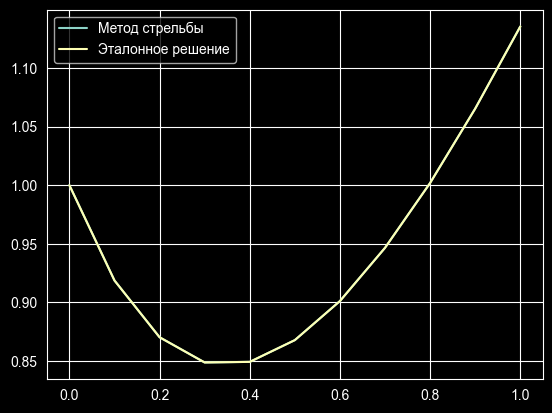

In [318]:
sns.lineplot(x=x, y=y_shooting, label="Метод стрельбы")
sns.lineplot(x=x, y=y_etalon_f, label="Эталонное решение")

## Конечно-разностный метод

Коэффициенты стандартного вида уравнения

Сначала приводим уравнение к виду:

$
y''+p(x)y'+q(x)y=0.
$

Делим исходное уравнение на \(2x+1\):

$
y''+\frac{4x}{2x+1}y'-\frac{4}{2x+1}y=0.
$

Отсюда:

$
p(x)=\frac{4x}{2x+1},\qquad q(x)=-\frac{4}{2x+1}.
$

In [319]:
p = (4 * x) / (2 * x + 1)
q = -4 / (2 * x + 1)

Левое граничное условие:
$
y'(0)=-1
$

Аппроксимация:
$
\frac{y_1-y_0}{h}=-1
$

Итого:
$
-\frac{1}{h}y_0+\frac{1}{h}y_1=-1
$

Внутренние узлы:
$
\left(1-\frac{p_i h}{2}\right)y_{i-1}
+
\left(-2+h^2q_i\right)y_i
+
\left(1+\frac{p_i h}{2}\right)y_{i+1}
=
0
$

Правое граничное условие:
$
y'(1)+2y(1)=3
$

Аппроксимация:
$
\frac{y_n-y_{n-1}}{h}+2y_n=3
$

Итого:
$
-\frac{1}{h}y_{n-1}
+
\left(\frac{1}{h}+2\right)y_n
=
3
$

Реализуем конечно-разностный метод для данной задачи Коши, используя указанные аппроксимации для граничных условий и внутренних узлов. Используем метод прогонки для решения получившейся трёхдиагональной системы.

In [320]:
def finite_difference(x_sample, p, q, h):
    # Составляем матрицу для метода прогонки
    n = len(x_sample) - 1
    A = np.zeros((n + 1, 3))
    b = np.zeros(n + 1)

    for i in range(len(x_sample)):
        if i == 0:
            A[i][1] = -1 / h
            A[i][2] = 1 / h
            b[i] = -1
        elif i == n:
            A[i][0] = -1 / h
            A[i][1] = 1 / h + 2
            b[i] = 3
        else:
            A[i][0] = 1 - p[i] * h / 2
            A[i][1] = -2 + h ** 2 * q[i]
            A[i][2] = 1 + p[i] * h / 2

    # Метод прогонки из прошлых ЛР
    n = len(x_sample)
    P, Q = np.zeros(n + 1, dtype=float), np.zeros(n + 1, dtype=float)

    P[0], Q[0] = 0, 0

    for i in range(0, n):
        P[i + 1] = -A[i, 2] / (A[i, 1] + A[i, 0] * P[i])
        Q[i + 1] = (b[i] - A[i, 0] * Q[i]) / (A[i, 1] + A[i, 0] * P[i])

    y_finite_difference_result = np.zeros(n, dtype=float)

    for i in range(n, 0, -1):
        if P[i] == 0:
            y_finite_difference_result[i - 1] = Q[i]
            continue
        y_finite_difference_result[i - 1] = P[i] * y_finite_difference_result[i] + Q[i]

    return y_finite_difference_result

Рассчитаем приближённые значения $y$ в узлах сетки, используя конечно-разностный метод:

In [321]:
y_finite_difference = finite_difference(x, p, q, h)

<Axes: >

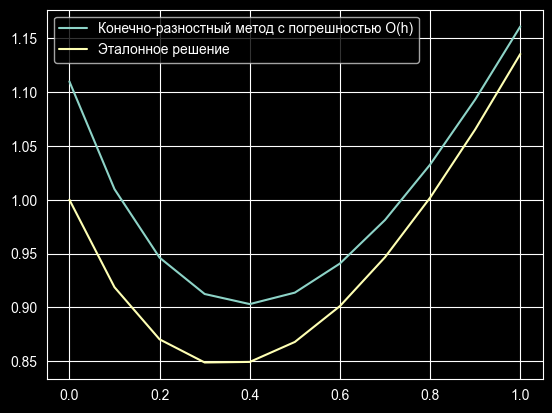

In [322]:
sns.lineplot(x=x, y=y_finite_difference, label="Конечно-разностный метод с погрешностью O(h)")
sns.lineplot(x=x, y=y_etalon_f, label="Эталонное решение")

На графике видно, что конечно-разностный метод с погрешностью $O(h)$ даёт заметно более грубое приближение, чем метод стрельбы, который имеет погрешность $O(h^4)$.

Погрешность конечно-разностного метода

In [323]:
print(error(y_finite_difference, y_etalon_f))

0.5981383213006737


# Валидация

## Метод Рунге–Ромберга–Ричардсона

Для оценки главного члена погрешности одно и то же решение посчитаем на двух сетках: с шагом \(h\) и с шагом \(h/2\). После этого решения сравниваются в общих узлах.


In [324]:
k = 2
smaller_h = h / k
x_smaller_h = np.arange(start, end + smaller_h, smaller_h)

Прогоним решения тех же задач на сетке с шагом h/2

In [325]:
p_smaller_h = (4 * x_smaller_h) / (2 * x_smaller_h + 1)
q_smaller_h = -4 / (2 * x_smaller_h + 1)

_, y_shooting_smaller_h, z_shooting_smaller_h = shooting_method(
    f_der_1,
    f_der_2,
    x_smaller_h,
    smaller_h,
    s0,
    s1,
    z0,
    eps
)
y_finite_difference_smaller_h = finite_difference(x_smaller_h, p_smaller_h, q_smaller_h, smaller_h)

Найдём погрешности по Рунге–Ромбергу

In [326]:
runge_romberg_shooting = runge_romberg_richardson(y_shooting_smaller_h, y_shooting, 4, k)
runge_romberg_finite_difference = runge_romberg_richardson(y_finite_difference_smaller_h, y_finite_difference, 2, k)

In [327]:
print(np.max(np.abs(runge_romberg_shooting)), np.max(np.abs(runge_romberg_finite_difference)))

3.6424752023478393e-07 0.018745822451503653


Уточнение решений и итоговый график

In [328]:
shooting_with_runge_romberg = y_shooting + runge_romberg_shooting
finite_difference_with_runge_romberg = y_finite_difference + runge_romberg_finite_difference

<Axes: >

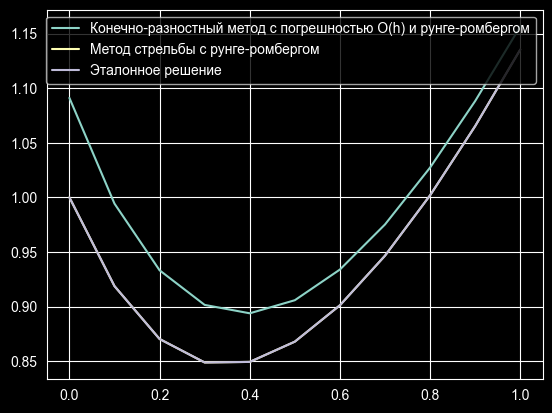

In [329]:
sns.lineplot(x=x, y=finite_difference_with_runge_romberg, label="Конечно-разностный метод с погрешностью O(h) и рунге-ромбергом")
sns.lineplot(x=x, y=shooting_with_runge_romberg, label="Метод стрельбы с рунге-ромбергом")
sns.lineplot(x=x, y=y_etalon_f, label="Эталонное решение")